In [12]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, accuracy_score

In [2]:
dataset = load_dataset("go_emotions", "simplified")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [3]:
def filter_single_label(data):
    return len(data["labels"]) == 1

def extract_single_label(data):
    return {"label": data["labels"][0]}

In [4]:
print(dataset["train"][0:10])

{'text': ["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers', "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.", 'Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝', 'We need more boards and to create a bit more space for [NAME]. Then we’ll be good.', 'Damn youtube and outrage drama is super lucrative for reddit', 'It might be linked to the trust factor of your friend.'], 'labels': [[27], [27], [2], [14], [3], [26], [15], [8, 20], [0], [27]], 'id': ['eebbqej', 'ed00q6i', 'eezlygj', 'ed7ypvh', 'ed0bdzj', 'edvnz26', 'ee3b6wu', 'ef4qmod', 'ed8wbdn', 'eczgv1o']}


In [5]:
dataset = dataset.filter(filter_single_label)
dataset = dataset.map(extract_single_label)

Filter:   0%|          | 0/43410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5426 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5427 [00:00<?, ? examples/s]

Map:   0%|          | 0/36308 [00:00<?, ? examples/s]

Map:   0%|          | 0/4548 [00:00<?, ? examples/s]

Map:   0%|          | 0/4590 [00:00<?, ? examples/s]

In [6]:
print(dataset)

for split in dataset.keys():
    print(f"Liczba przykładów w {split}: {len(dataset[split])}")

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id', 'label'],
        num_rows: 36308
    })
    validation: Dataset({
        features: ['text', 'labels', 'id', 'label'],
        num_rows: 4548
    })
    test: Dataset({
        features: ['text', 'labels', 'id', 'label'],
        num_rows: 4590
    })
})
Liczba przykładów w train: 36308
Liczba przykładów w validation: 4548
Liczba przykładów w test: 4590


In [7]:
models = {
    "DeBERTa": "microsoft/deberta-v3-base",
    "RoBERTa": "roberta-base",
    "ALBERT": "albert-base-v2"
}
num_labels = 28
results = {}

In [ ]:
!pip install evaluate

In [9]:
import evaluate
metrics = evaluate.combine(["accuracy", "f1"])

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    macro_f1 = evaluate.load("f1").compute(predictions=preds, references=labels, average="macro")["f1"]
    weighted_f1 = evaluate.load("f1").compute(predictions=preds, references=labels, average="weighted")["f1"]
    acc = evaluate.load("accuracy").compute(predictions=preds, references=labels)["accuracy"]
    return {"accuracy": acc, "f1_macro": macro_f1, "f1_weighted": weighted_f1}

In [11]:
DistilBERT = "distilbert-base-uncased"
print ("Trening modelu DistilBERT")

tokenizer = AutoTokenizer.from_pretrained(DistilBERT)
model = AutoModelForSequenceClassification.from_pretrained(DistilBERT, num_labels=num_labels)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
train_subset = tokenized_datasets["train"].shuffle(seed=76).select(range(10000))
test_subset = tokenized_datasets["validation"].shuffle(seed=77).select(range(1000))

training_args = TrainingArguments(
        output_dir=f"./results_distilbert",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=50,
        fp16=True
    )

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=test_subset,
        compute_metrics=compute_metrics,
    )

trainer.train()

predictions_output = trainer.predict(test_subset)
raw_preds = predictions_output.predictions
hard_preds = np.argmax(raw_preds, axis=-1)

results["distilbert"] = {
    "true": test_subset["labels"],
    "pred": hard_preds,
    "metrics": predictions_output.metrics
}

Trening modelu DistilBERT


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/4548 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.891880,1.858062,0.503000,0.184503,0.392558
2,1.592360,1.651423,0.549000,0.275314,0.465815
3,1.451597,1.615440,0.547000,0.293307,0.482907


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]

print(classification_report(
    results['distilbert']['true'],
    results['distilbert']['pred'],
    labels=range(len(emotions)),
    target_names=emotions
))

acc = accuracy_score(results['distilbert']['true'], results['distilbert']['pred'])
kappa = cohen_kappa_score(results['distilbert']['true'], results['distilbert']['pred'])

print(f"Ogólna Dokładność (Accuracy): {acc:.4f}")
print(f"Współczynnik Cohen's Kappa: {kappa:.4f} (im bliżej 1.0, tym lepiej)")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

                precision    recall  f1-score   support

    admiration       0.56      0.79      0.66        73
     amusement       0.71      0.83      0.76        47
         anger       0.51      0.58      0.55        31
     annoyance       0.11      0.07      0.08        30
      approval       0.50      0.14      0.22        57
        caring       1.00      0.04      0.08        24
     confusion       0.40      0.09      0.15        22
     curiosity       0.29      0.42      0.34        36
        desire       0.00      0.00      0.00        10
disappointment       0.00      0.00      0.00        33
   disapproval       0.42      0.09      0.15        55
       disgust       0.00      0.00      0.00        10
 embarrassment       0.00      0.00      0.00         4
    excitement       0.00      0.00      0.00         8
          fear       0.00      0.00      0.00        11
     gratitude       0.90      0.90      0.90        51
         grief       0.00      0.00      0.00  

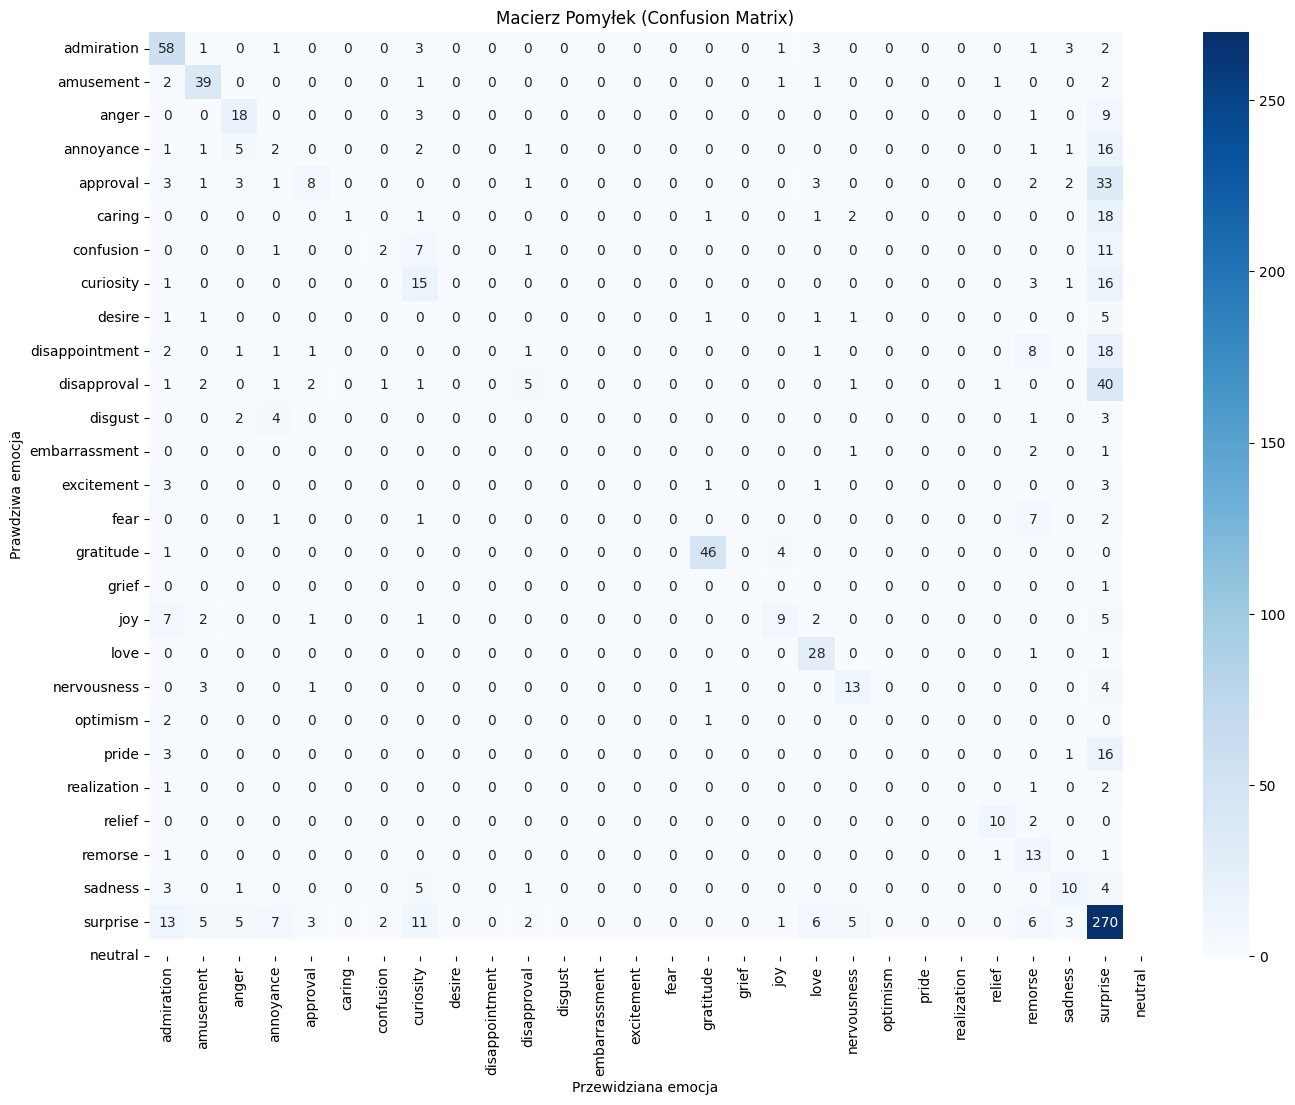

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

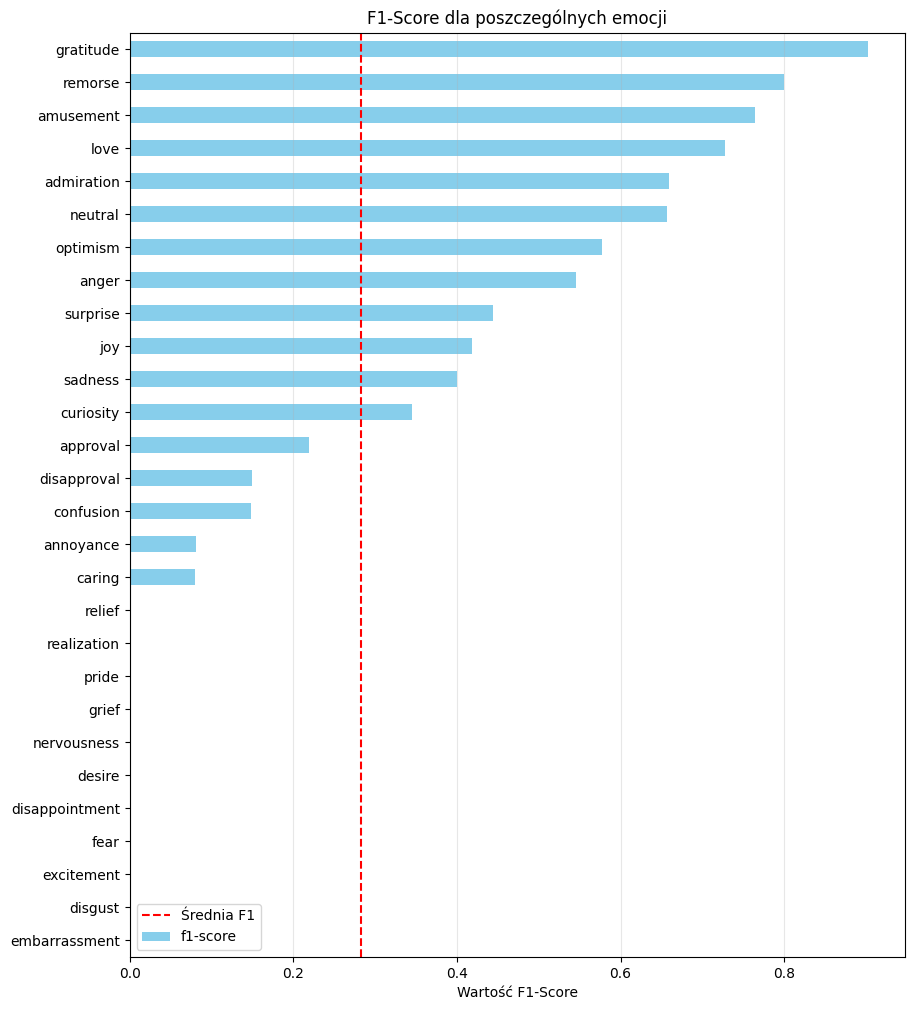

In [16]:
cm = confusion_matrix(results['distilbert']['true'], results['distilbert']['pred'])
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions, yticklabels=emotions)
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.xlabel('Przewidziana emocja')
plt.ylabel('Prawdziwa emocja')
plt.show()
report_dict = classification_report(results['distilbert']['true'], results['distilbert']['pred'], labels=range(len(emotions)), target_names=emotions, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose().iloc[:-3]
plt.figure(figsize=(10, 12))
df_report['f1-score'].sort_values().plot(kind='barh', color='skyblue')
plt.axvline(x=df_report['f1-score'].mean(), color='red', linestyle='--', label='Średnia F1')
plt.title('F1-Score dla poszczególnych emocji')
plt.xlabel('Wartość F1-Score')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [20]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0
)
txt = "I don't really know what is going on."
res = classifier(txt)[0]
label_str = res['label']
label_id = int(label_str.split('_')[-1])
emotion = emotions[label_id]

val = res['score'] * 100

print(f"Tekst: \"{txt}\"")
print(f"Wykryta emocja: {emotion.upper()}")
print(f"Pewność modelu: {val:.2f}%")

Tekst: "I don't really know what is going on."
Wykryta emocja: CONFUSION
Pewność modelu: 25.41%
